## Figure 4 d: Class sum of gene expression of one combination and its single agents relative to the IL-1B treated
#### Wooseok Lee

In [1]:
# Minimal imports for class-summed barplots (mean ± SEM)
import os
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.stats


In [2]:
mac_cmb01 = sc.read_h5ad('/home/Nathan94/insitu-seq/geml/dataset/mac_cmb01.sct.h5ad')
mac_sin01 = sc.read_h5ad('/home/Nathan94/insitu-seq/geml/dataset/mac_sin01.sct.h5ad')

In [ ]:
# Gene classes
Anabolic_genes = ['Acan','Sox9','Col2a1','Matn1','Matn3', 'Ucma','Ccnd3','Gadd45g','Pth1r','Gm26633','Col27a1']
Catabolic_genes = ['Mmp3','Mmp13','Il6', 'Il17b', 'Adamts5','Igfbp3','Ccl2','Cxcl5','Cxcl1','Fosl2','Tlr2','Tnfrsf1b']
Housekeeping_genes = ['Hprt','Actb','Gapdh','B2m','Ubc','Ppia','Rpl23']

# Use only anabolic and catabolic genes for class plots
GI_genes = Anabolic_genes + Catabolic_genes


In [4]:
# Mean ± SEM for a 1D array
def mean_sem_interval(data):
    a = np.array(data, dtype=float)
    m = np.mean(a)
    se = scipy.stats.sem(a)
    return m, m - se, m + se


In [5]:
# Compute class-summed Δ log1p expression (mean ± SEM), baseline = 'inflammatory'
def sem_of_class_sum(adata, pert, genes, control_label='inflammatory'):
    ctrl = adata[adata.obs['drug_name'] == control_label][:, list(genes)].X
    pert = adata[adata.obs['drug_name'] == pert][:, list(genes)].X

    # ensure dense
    try: ctrl = ctrl.toarray()
    except Exception: pass
    try: pertx = pert.toarray()
    except Exception: pertx = pert

    # log1p transform
    ctrl = np.log1p(ctrl)
    pertx = np.log1p(pertx)

    # baseline-correct per gene
    ctrl_mean = ctrl.mean(axis=0, keepdims=True)     # shape (1, G)
    corrected = pertx - ctrl_mean                    # shape (N, G)

    # sum across class genes per cell
    class_scores = corrected.sum(axis=1)             # shape (N,)

    # return mean ± SEM
    return mean_sem_interval(class_scores)


In [6]:
# Select perturbations
combo = "SB431542&SANT-1"
x_g = 'SB431542'
y_g = 'SANT-1'


Saved figure to: /home/Nathan94/insitu-seq/geml/figures/fig4d_sem_classsum_clean_il17bAnaboilc.pdf


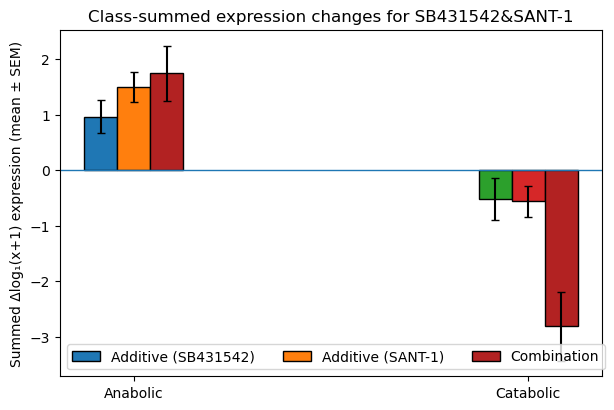

In [ ]:
# Plot class-summed bars (mean ± SEM): Additive(x_g), Combination, Additive(y_g)
from collections import OrderedDict

classes = OrderedDict([
    ('Anabolic', Anabolic_genes),
    ('Catabolic', Catabolic_genes),
])

fig, ax = plt.subplots(figsize=(7, 4.5))
width = 0.25
xticks = []
xticklabels = []

g1 = x_g
g2 = y_g

for i, (cls_name, genes) in enumerate(classes.items()):
    m_x, lo_x, hi_x = sem_of_class_sum(mac_sin01, g1, genes)
    m_c, lo_c, hi_c = sem_of_class_sum(mac_cmb01, combo, genes)
    m_y, lo_y, hi_y = sem_of_class_sum(mac_sin01, g2, genes)

    se_x = m_x - lo_x
    se_c = m_c - lo_c
    se_y = m_y - lo_y

    base = i * 3.0

    ax.bar(base - width, m_x, width=width, yerr=se_x, edgecolor='black', linewidth=1, capsize=3, label=f'Additive ({g1})' if i == 0 else None)
    ax.bar(base,         m_y, width=width, yerr=se_y, edgecolor='black', linewidth=1, capsize=3, label=f'Additive ({g2})' if i == 0 else None)
    ax.bar(base + width, m_c, width=width, yerr=se_c, edgecolor='black', linewidth=1, capsize=3, color='firebrick', label='Combination' if i == 0 else None)

    xticks.append(base)
    xticklabels.append(cls_name)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.axhline(y=0, linewidth=1)

ax.set_ylabel('Summed Δlog₁(x+1) expression (mean ± SEM)')
ax.set_title('Class-summed expression changes for ' + combo)
ax.legend(ncol=3, loc='lower left')

# Save
out_pdf = '/home/Nathan94/insitu-seq/geml/figures/fig4d_sem_classsum_clean.pdf'
os.makedirs(os.path.dirname(out_pdf), exist_ok=True)
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
print('Saved figure to:', out_pdf)
